# Segment-level lift & heterogeneous treatment effects (Week 6)

Exploratory read on **`marts.segment_performance_metrics`** — treatment vs control outcomes by `audience_segment_id` × `primary_geo_id` within each campaign.

**Primary input:** `data/processed/segment_performance_metrics.csv` (from `scripts/run_incrementality.py --export-csv` after building marts).

**Definitions** match `sql/marts/segment_performance_metrics.sql`: campaign-attributed conversions in the campaign date window; lift and incremental orders/revenue use the same RCT-style formulas as campaign-level `experiment_lift_metrics`.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import display

# Project root: cwd, or parent when the kernel runs from ``notebooks/``
ROOT = Path.cwd()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

PROCESSED = ROOT / "data" / "processed"
SEGMENT_CSV = PROCESSED / "segment_performance_metrics.csv"
CAMPAIGN_CSV = PROCESSED / "experiment_lift_metrics.csv"

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if pd.notna(x) and abs(x) < 1e6 else f"{x:,.2f}")

print(f"ROOT={ROOT}")
print(f"PROCESSED={PROCESSED}")

ROOT=/Users/pratikdahal/Desktop/internship/retail-media-platform
PROCESSED=/Users/pratikdahal/Desktop/internship/retail-media-platform/data/processed


## Load segment lift table

If the CSV is missing, run the DB pipeline (load → staging → marts) and `python scripts/run_incrementality.py --export-csv`.

In [2]:
if not SEGMENT_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {SEGMENT_CSV}. Build marts and export: "
        "``python scripts/run_incrementality.py --export-csv``"
    )

seg = pd.read_csv(SEGMENT_CSV)
print(f"Loaded {len(seg):,} rows from {SEGMENT_CSV.name}")

Loaded 24 rows from segment_performance_metrics.csv


## Schema, dtypes, and row counts

Quick sanity check before ranking segments.

In [3]:
print("shape:", seg.shape)
print()
print(seg.dtypes)
print()
display(seg.head(10))

shape: (24, 11)

campaign_id                    int64
audience_segment_id            int64
primary_geo_id                 int64
treatment_member_count         int64
control_member_count           int64
treatment_conversion_rate    float64
control_conversion_rate      float64
absolute_lift                float64
relative_lift                float64
incremental_orders           float64
incremental_revenue          float64
dtype: object



,campaign_id,audience_segment_id,primary_geo_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift,incremental_orders,incremental_revenue
0,23,5,10,36,11,0.1111,0.0909,0.0202,0.2222,0.7273,44.0100
1,14,2,18,37,9,0.1081,0.0000,0.1081,NaN,4.0000,191.8700
2,16,1,20,26,17,0.0385,0.0000,0.0385,NaN,1.0000,29.1800
3,17,4,16,39,18,0.3590,0.0556,0.3034,5.4615,11.8333,450.6900
4,21,5,23,39,23,0.1282,0.0000,0.1282,NaN,5.0000,198.0600
5,11,1,33,45,12,0.1556,0.0000,0.1556,NaN,7.0000,317.1000
6,12,5,45,27,13,0.2963,0.0000,0.2963,NaN,8.0000,313.9500
7,13,5,36,35,14,0.2286,0.0000,0.2286,NaN,8.0000,351.9000
8,24,4,23,48,13,0.2083,0.0000,0.2083,NaN,10.0000,478.0800
9,4,3,18,27,16,0.3333,0.0000,0.3333,NaN,9.0000,329.5600


## Analysis cohort: cells with both arms

`relative_lift` and incremental metrics are only defined when **both** treatment and control have members in the segment cell (`treatment_member_count > 0` and `control_member_count > 0`). We use this subset for lift rankings.

In [4]:
both_arms = (seg["treatment_member_count"] > 0) & (seg["control_member_count"] > 0)
seg_ok = seg.loc[both_arms].copy()
print(f"Rows with both arms: {len(seg_ok):,} / {len(seg):,}")

# Helpful label for plots/tables
seg_ok["segment_label"] = (
    "c"
    + seg_ok["campaign_id"].astype(str)
    + "_a"
    + seg_ok["audience_segment_id"].fillna(-1).astype(int).astype(str)
    + "_g"
    + seg_ok["primary_geo_id"].fillna(-1).astype(int).astype(str)
)

Rows with both arms: 24 / 24


## Strongest and weakest **absolute** lift (CVR_T − CVR_C)

Positive `absolute_lift` means a higher campaign-attributed conversion rate in treatment than control for that segment cell. `relative_lift` is undefined when control CVR is 0 (stored as NaN in CSV).

In [5]:
rank = seg_ok.sort_values("absolute_lift", ascending=False)
cols_show = [
    "campaign_id",
    "audience_segment_id",
    "primary_geo_id",
    "treatment_member_count",
    "control_member_count",
    "treatment_conversion_rate",
    "control_conversion_rate",
    "absolute_lift",
    "relative_lift",
]

print("Top 10 by absolute_lift")
display(rank[cols_show].head(10))

print("\nBottom 10 by absolute_lift")
display(rank[cols_show].tail(10).iloc[::-1])

Top 10 by absolute_lift


,campaign_id,audience_segment_id,primary_geo_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift
16,6,3,24,34,16,0.4118,0.0000,0.4118,NaN
9,4,3,18,27,16,0.3333,0.0000,0.3333,NaN
3,17,4,16,39,18,0.3590,0.0556,0.3034,5.4615
19,15,4,47,31,18,0.3548,0.0556,0.2993,5.3871
6,12,5,45,27,13,0.2963,0.0000,0.2963,NaN
15,10,5,36,30,19,0.3667,0.1053,0.2614,2.4833
20,1,4,38,28,17,0.2500,0.0000,0.2500,NaN
7,13,5,36,35,14,0.2286,0.0000,0.2286,NaN
12,2,3,37,40,16,0.2750,0.0625,0.2125,3.4000
8,24,4,23,48,13,0.2083,0.0000,0.2083,NaN



Bottom 10 by absolute_lift


,campaign_id,audience_segment_id,primary_geo_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift
0,23,5,10,36,11,0.1111,0.0909,0.0202,0.2222
17,8,1,27,26,20,0.0385,0.0000,0.0385,NaN
2,16,1,20,26,17,0.0385,0.0000,0.0385,NaN
23,20,1,4,32,14,0.0625,0.0000,0.0625,NaN
13,22,3,39,31,16,0.0645,0.0000,0.0645,NaN
1,14,2,18,37,9,0.1081,0.0000,0.1081,NaN
22,3,5,10,32,14,0.1875,0.0714,0.1161,1.6250
10,19,2,18,39,8,0.1282,0.0000,0.1282,NaN
4,21,5,23,39,23,0.1282,0.0000,0.1282,NaN
11,5,3,23,23,19,0.1304,0.0000,0.1304,NaN


## Incremental orders and incremental revenue by segment

RCT-scaled excess vs control within each cell: `orders_T − n_T×(orders_C/n_C)` and same for revenue (see mart SQL comments).

In [6]:
inc_cols = cols_show + ["incremental_orders", "incremental_revenue"]
by_inc = seg_ok.sort_values("incremental_revenue", ascending=False)
print("Top 10 by incremental_revenue (segment cells)")
display(by_inc[inc_cols].head(10))

print("\nTop 10 by incremental_orders")
display(seg_ok.sort_values("incremental_orders", ascending=False)[inc_cols].head(10))

Top 10 by incremental_revenue (segment cells)


,campaign_id,audience_segment_id,primary_geo_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift,incremental_orders,incremental_revenue
16,6,3,24,34,16,0.4118,0.0000,0.4118,NaN,14.0000,671.6400
8,24,4,23,48,13,0.2083,0.0000,0.2083,NaN,10.0000,478.0800
3,17,4,16,39,18,0.3590,0.0556,0.3034,5.4615,11.8333,450.6900
18,9,3,8,55,9,0.2000,0.0000,0.2000,NaN,11.0000,438.5900
19,15,4,47,31,18,0.3548,0.0556,0.2993,5.3871,9.2778,405.6600
12,2,3,37,40,16,0.2750,0.0625,0.2125,3.4000,8.5000,395.8700
7,13,5,36,35,14,0.2286,0.0000,0.2286,NaN,8.0000,351.9000
9,4,3,18,27,16,0.3333,0.0000,0.3333,NaN,9.0000,329.5600
15,10,5,36,30,19,0.3667,0.1053,0.2614,2.4833,7.8421,324.5100
5,11,1,33,45,12,0.1556,0.0000,0.1556,NaN,7.0000,317.1000



Top 10 by incremental_orders


,campaign_id,audience_segment_id,primary_geo_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift,incremental_orders,incremental_revenue
16,6,3,24,34,16,0.4118,0.0000,0.4118,NaN,14.0000,671.6400
3,17,4,16,39,18,0.3590,0.0556,0.3034,5.4615,11.8333,450.6900
18,9,3,8,55,9,0.2000,0.0000,0.2000,NaN,11.0000,438.5900
8,24,4,23,48,13,0.2083,0.0000,0.2083,NaN,10.0000,478.0800
19,15,4,47,31,18,0.3548,0.0556,0.2993,5.3871,9.2778,405.6600
9,4,3,18,27,16,0.3333,0.0000,0.3333,NaN,9.0000,329.5600
12,2,3,37,40,16,0.2750,0.0625,0.2125,3.4000,8.5000,395.8700
7,13,5,36,35,14,0.2286,0.0000,0.2286,NaN,8.0000,351.9000
6,12,5,45,27,13,0.2963,0.0000,0.2963,NaN,8.0000,313.9500
15,10,5,36,30,19,0.3667,0.1053,0.2614,2.4833,7.8421,324.5100


## Simple chart: top segment cells by incremental revenue

Requires **matplotlib** (install with `pip install matplotlib` if the import fails).

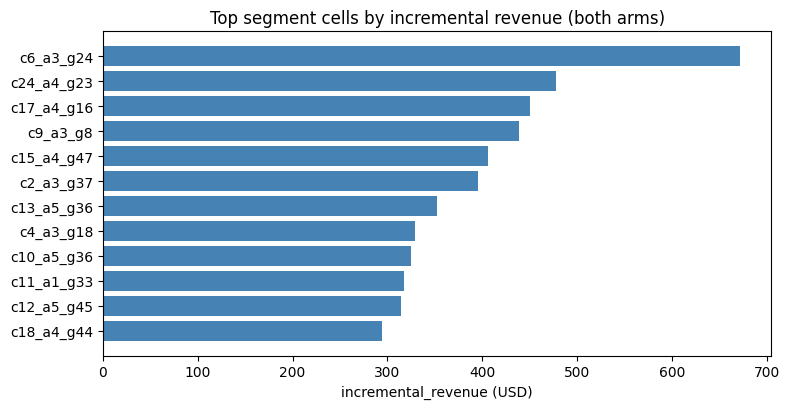

In [7]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("Skip chart: install matplotlib")

if plt is not None and len(seg_ok) > 0:
    topn = min(12, len(seg_ok))
    sub = seg_ok.nlargest(topn, "incremental_revenue").sort_values("incremental_revenue")
    fig, ax = plt.subplots(figsize=(8, max(4, topn * 0.35)))
    ax.barh(sub["segment_label"], sub["incremental_revenue"].astype(float), color="steelblue")
    ax.set_xlabel("incremental_revenue (USD)")
    ax.set_title("Top segment cells by incremental revenue (both arms)")
    fig.tight_layout()
    plt.show()
else:
    print("No rows to plot.")

## Optional: campaign-level lift (sanity check)

Compare segment findings to rolled-up `experiment_lift_metrics` when the CSV exists.

In [8]:
if CAMPAIGN_CSV.is_file():
    camp = pd.read_csv(CAMPAIGN_CSV)
    print(f"Loaded {len(camp):,} campaign rows")
    display(
        camp[
            [
                "campaign_id",
                "treatment_member_count",
                "control_member_count",
                "treatment_conversion_rate",
                "control_conversion_rate",
                "absolute_lift",
                "incremental_revenue",
            ]
        ]
    )
else:
    print(f"Optional file not found: {CAMPAIGN_CSV}")

Loaded 24 campaign rows


,campaign_id,treatment_member_count,control_member_count,treatment_conversion_rate,control_conversion_rate,absolute_lift,incremental_revenue
0,22,31,16,0.0645,0.0000,0.0645,69.5200
1,11,45,12,0.1556,0.0000,0.1556,317.1000
2,9,55,9,0.2182,0.0000,0.2182,468.8300
3,15,31,18,0.3548,0.0556,0.2993,458.2600
4,19,39,8,0.1282,0.0000,0.1282,155.7500
5,21,39,23,0.1282,0.0000,0.1282,198.0600
6,3,32,14,0.1875,0.0714,0.1161,182.6700
7,17,39,18,0.3590,0.1111,0.2479,415.3900
8,5,23,19,0.1739,0.0000,0.1739,164.6200
9,4,27,16,0.3333,0.0000,0.3333,329.5600
